In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
config_path = "experiments/benchmark_output_files/mouse_brain.yaml"

In [3]:
from src.experiments_analysis.analysis_simulated_data_pipeline import analysis
import yaml
from pathlib import Path as P

cfg = yaml.safe_load(open(config_path))

output_dir = cfg["output_dir"]
runs = cfg["runs"]
dividing_by_ratio_baselines = cfg["dividing_by_ratio_baselines"]
not_factor_based_baseline = cfg["not_factor_based_baseline"]
supp_baselines_dir = cfg["supp_baselines_dir"]

main_publi_output_folder = P(cfg["main_publi_output_folder"])
main_publi_output_folder.mkdir(exist_ok=True, parents=True)
supp_publi_output_folder = P(cfg["supp_publi_output_folder"])
supp_publi_output_folder.mkdir(exist_ok=True, parents=True)

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [4]:
analysis(
    output_dir,
    runs,
    dividing_by_ratio_baselines,
    not_factor_based_baseline,
    supp_baselines_dir,
    synthetic_data=False
)

,name,converged
0,ours,True
1,ours__P2_identity,True
2,ours__none_init,True
3,original,NaN
4,dividing_median_ratio,NaN
5,dividing_median,NaN
6,dividing_median_quantile_nucl,NaN
7,dividing_99_quantile_nucl,NaN
8,dividing_99_quantile,NaN
9,2SN,NaN


/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  destriped_summary_df.groupby("name").apply(select_method).reset_index(drop=True)


2SN 0
bin_level_normalization 1
dividing_99_quantile 2
dividing_99_quantile_nucl 3
dividing_median 4
dividing_median_quantile_nucl 5
dividing_median_ratio 6
original 7
ours 8
ours__P2_identity 9
ours__none_init 10


striping intensity in cytoplasm
striping intensity in cytoplasm
striping intensity in cytoplasm + nucleus
striping intensity in cytoplasm + nucleus


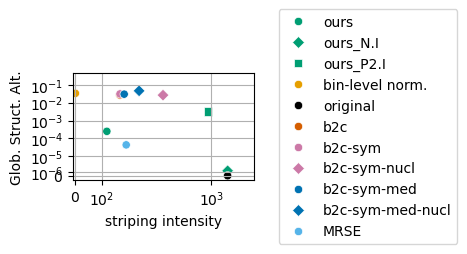

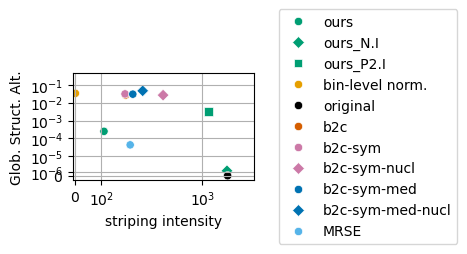

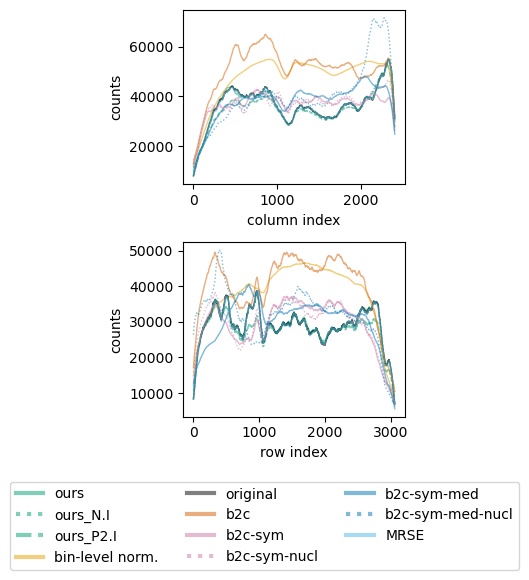

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:945: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


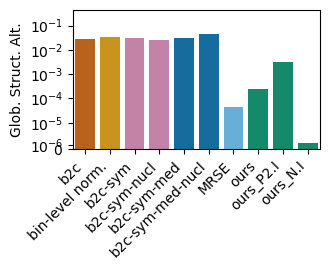

/Users/pmalsot/Documents_no_iCloud/destriping-GLM-rebuttals/src/experiments_analysis/analysis_plots.py:945: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


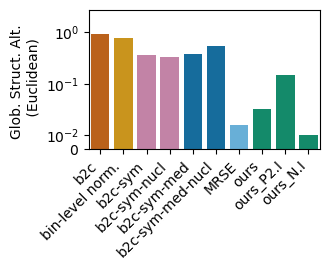

In [4]:
from src.experiments_analysis.analysis_plots import global_structure_plot_all_methods
from pathlib import Path as P

global_structure_analysis_folder = P(output_dir) / "global_structure_analysis"
supp_publi_output_folder = cfg["supp_publi_output_folder"]
P(supp_publi_output_folder).mkdir(exist_ok=True, parents=True)

global_structure_plot_all_methods(global_structure_analysis_folder, supp_publi_output_folder)

## Slides plots

### Brain and region overview

Using vmin, vmax = 1.0 550.0


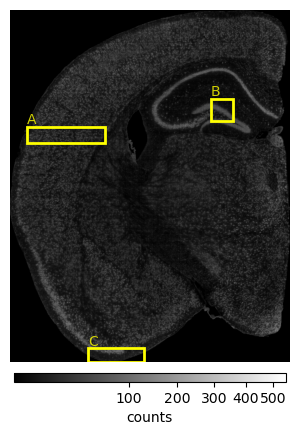

In [5]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots,
)
from src.experiments_analysis.plots_ismb import model_name_replacement_dict, colorblind_palette
from src.experiments_analysis.analysis_plots import region_overview_plot
from matplotlib.colors import PowerNorm
from cmap import Colormap
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from pathlib import Path as P
import numpy as np

height_colorbar=0.092

regions = {
    "bottom edge": (slice(-120, None), slice(700, 1200)),
    "macro-stripe": (slice(1050, 1200), slice(150, 850)),
    "center": (slice(800, 1000), slice(1800, 2000))
}

colors_region = {
    "bottom edge": "yellow",
    "macro-stripe": "yellow",
    "center": "yellow"
}

abbr_region = {"macro-stripe": "A",
                "center": "B",
                "bottom edge": "C"}
imshow_kwargs = {}
rectangle_kwargs = {"alpha": 1}

norm = PowerNorm(gamma=0.5) #otherwise we don't see anything


region_overview_plot("original", regions, colors_region, abbr_region, global_structure_analysis_folder, model_name_replacement_dict, norm, height_colorbar, imshow_kwargs=imshow_kwargs, rectangle_kwargs=rectangle_kwargs)

plt.savefig(P(main_publi_output_folder) / "brain_regions_overview.pdf")

### Bottom edge

Using vmin, vmax = 0.48244717550798427 345.0


/var/folders/4c/07__r2qx0d76dq5_bnfgp4sr0000gn/T/ipykernel_20162/1762648577.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


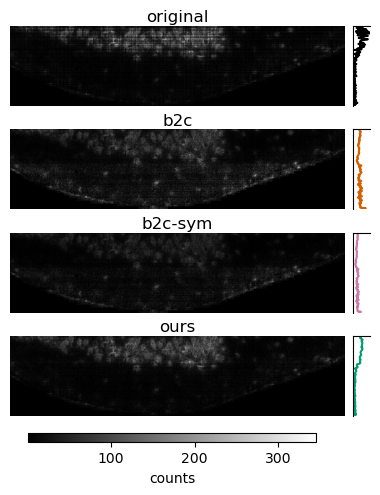

In [6]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from src.experiments_analysis.analysis_plots import add_curves_to_right, align_left_right_plots, get_summary_count_per_row_for_region
from src.experiments_analysis.plots_ismb import color_dict

to_plot = ["original", "b2c", "b2c-sym", "ours"]
region_slice = regions["bottom edge"]

df = get_summary_count_per_row_for_region(
    output_dir, region_slice, to_plot, model_name_replacement_dict
)

with mpl.rc_context({"axes.titlepad": 3}):
    fig, axes = plt.subplots(
        nrows=len(to_plot),
        ncols=2,
        figsize=(3.4 + 0.2, 1.15 * len(to_plot)),
        gridspec_kw={"width_ratios": [1.0, 0.05], "wspace": 0.05, "hspace": 0.0},
        sharey="row",
    )

    compare_destriped_data_plots(
        to_plot,
        global_structure_analysis_folder,
        region_slice,
        model_name_replacement_dict,
        axes=axes[:, 0],
        colorbar_on=False,
        aspect="equal",
    )
    [ax.axis("off") for ax in axes[:,0]]

    add_curves_to_right(axes, to_plot, df, color_dict)

    plt.tight_layout()
    fig.subplots_adjust(left=0, right=1, bottom=0.08, top=0.98)

    left_images = []
    for ax in axes[:, 0]:
        left_images.extend(ax.get_images())
    last_im = left_images[-1] if left_images else None
    cax = fig.add_axes([0.05, 0.05, 0.8, 0.02])
    cbar = fig.colorbar(last_im, cax=cax, orientation="horizontal")
    cbar.set_label("counts")

    align_left_right_plots(fig, axes)

    plt.savefig(P(main_publi_output_folder) / "slide_bottom_edge.pdf")
    plt.show()

In [7]:
height_colorbar = 0.02 * 1.15 * len(to_plot)
print(f"{height_colorbar=}")

height_colorbar=0.092


### Macro-stripe

Using vmin, vmax = 0.0 550.0


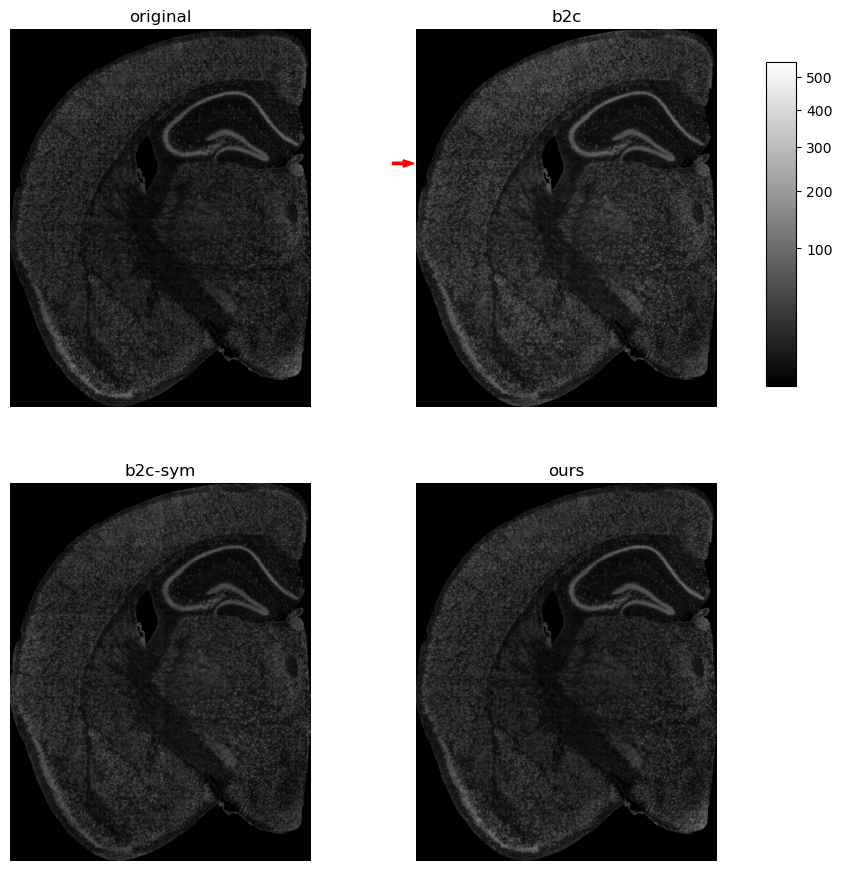

In [8]:
import matplotlib.pyplot as plt
from pathlib import Path as P
from matplotlib.colors import PowerNorm
import numpy as np

to_plot = ["original", "b2c", "b2c-sym", "ours"]
region_slice = (slice(None, None), slice(None, None))
fig, axes = plt.subplots(2,2, figsize=(5 *2, 5.4 * 2))
axes = compare_destriped_data_plots(to_plot, global_structure_analysis_folder, region_slice, model_name_replacement_dict, axes = axes.flatten())

new_norm = PowerNorm(gamma=0.5)
[ax.images[0].set_norm(new_norm) for ax in axes]
[ax.axis("off") for ax in axes]

for cax in np.array(fig.axes).flatten():
    if (cax.get_label() != "<colorbar>"):
        cax.get_images()[0].colorbar.remove()

images = []
for ax in fig.axes:
    for artist in ax.get_images():
        images.append(artist)
fig.subplots_adjust(right=0.87)
cax = fig.add_axes([0.92, 0.55, 0.03, 0.3])
fig.colorbar(images[0], cax=cax)

lims = fig.axes[1].get_xlim()
fig.axes[1].arrow(-200, 1120,180,0.,fc='r',ec='r',clip_on=False, width = 20, length_includes_head=True)
fig.axes[1].set_xlim(lims)

plt.savefig(P(supp_publi_output_folder) / "slide_whole.pdf")

plt.show()

### Macro stripe zoom

Using vmin, vmax = 0.44424001480327074 225.0
h_cbar=0.02


/var/folders/4c/07__r2qx0d76dq5_bnfgp4sr0000gn/T/ipykernel_20162/1940585684.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


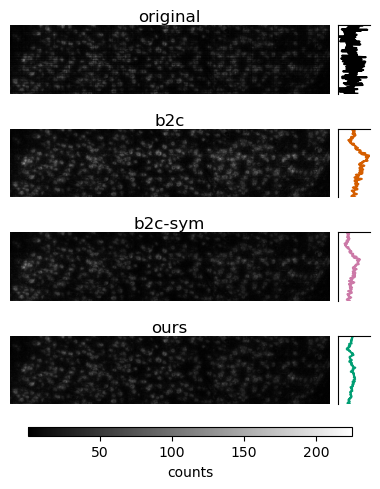

In [9]:

import matplotlib.pyplot as plt
from pathlib import Path as P
import numpy as np

height_colorbar=0.092

to_plot = ["original", "b2c", "b2c-sym", "ours"]
region_slice = regions["macro-stripe"]
df = get_summary_count_per_row_for_region(output_dir, region_slice, to_plot, model_name_replacement_dict, fun = "mean")

fig, axes = plt.subplots(
    nrows=len(to_plot),
    ncols=2,
    figsize=(3.4 + 0.2, 1.15 * len(to_plot)),
    gridspec_kw={"width_ratios": [1.0, 0.1], "wspace": 0.05, "hspace": 0.0},
    sharey="row",
)
with mpl.rc_context({'axes.titlepad': 3}):
    axes_left = compare_destriped_data_plots(to_plot, global_structure_analysis_folder, region_slice, model_name_replacement_dict, axes = axes[:, 0].flatten(), colorbar_on = False, aspect = "equal")


    [ax.axis("off") for ax in axes_left]

    add_curves_to_right(axes, to_plot, df, color_dict)

    images = []
    for ax in fig.axes:
        for artist in ax.get_images():   # returns list of AxesImage objects
            images.append(artist)
    align_left_right_plots(fig, axes)
    plt.tight_layout()
    fig.subplots_adjust(left = 0, right = 1, bottom = 0.08, top = 0.98, hspace=0, wspace = 0)
    h_cbar = height_colorbar / fig.get_size_inches()[1]
    print(f"{h_cbar=}")
    cax = fig.add_axes([0.05, 0.05, 0.9, h_cbar])
    cbar = fig.colorbar(images[-1], cax=cax, orientation="horizontal")
    cbar.set_label("counts")

    align_left_right_plots(fig, axes)

    plt.savefig(P(main_publi_output_folder) / "macro_stripe_zoom.pdf")

    plt.show()

### Center

Using vmin, vmax = 0.27983412697483395 208.0


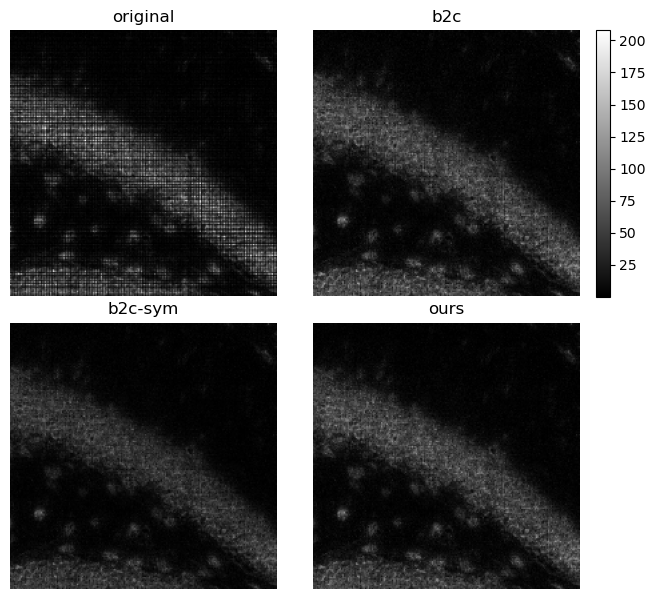

In [10]:
import matplotlib.pyplot as plt
from pathlib import Path as P
from matplotlib.colors import PowerNorm
import numpy as np

to_plot = ["original", "b2c", "b2c-sym", "ours"]
region_slice = (slice(800, 1000), slice(1800, 2000))
fig, axes = plt.subplots(2,2, figsize=(3.4 *2, 3 * 2))
axes = compare_destriped_data_plots(to_plot, global_structure_analysis_folder, region_slice, model_name_replacement_dict, axes = axes.flatten())

[ax.axis("off") for ax in axes]

for cax in np.array(fig.axes).flatten():
    if (cax.get_label() != "<colorbar>") and (cax.get_title() != "b2c"):
        cax.get_images()[0].colorbar.ax.set_visible(False)

plt.tight_layout()

plt.savefig(P(main_publi_output_folder) / "slide_center.pdf")

plt.show()